<img src="https://assets-datascientest.s3-eu-west-1.amazonaws.com/train/logo_datascientest.png" style="height:150px">

<hr style="border-width:2px;border-color:#75DFC1">

<center><h1> ORT : Modèle de Gompertz bayésien avec PyMC </h1></center>

<hr style="border-width:2px;border-color:#75DFC1">

> Dans ce notebook, nous proposons une approche alternative à la méthode de **machine learning** précédemment utilisée. Cette nouvelle approche vise à **intégrer explicitement les connaissances biologiques fournies par les experts du domaine**.
>
> Suite à des échanges avec le biologiste responsable du projet, il apparaît pertinent d’utiliser un **modèle de Gompertz** pour décrire l’évolution de la couverture corallienne.

## Modèle de Gompertz

> Le modèle de Gompertz est couramment utilisé pour modéliser des dynamiques de croissance dépendantes de la densité. Il s’écrit sous la forme :
>
$$
\frac{dC}{dt} = r \, C \, \log\left(\frac{K}{C}\right)
$$
>
> où :
> - $C$ : couverture corallienne  
> - $r$ : taux de croissance (ou de récupération)  
> - $K$ : capacité de charge  
> 
> Dans notre cas, cette dynamique est reformulée en temps discret et paramétrée avec :
> - $r$ : taux de récupération  
> - $a$ : paramètre de dépendance à la densité : il est équivlent à *1/K*
> 
> L’objectif est donc d’estimer ces deux paramètres.

## Prise en compte de la structure des données

> Contrairement à l’approche de machine learning où les données étaient moyennées (une valeur par récif et par année), nous exploitons ici toute la richesse des données :
> 
> - plusieurs **transects** dans plusieurs sites sur chaque récif  
> - plusieurs **mesures par année**  
> - variabilité entre récifs et entre clusters  
>
> Cela permet de mieux capturer la variabilité spatiale et écologique.

## Structure hiérarchique du modèle

> Le modèle est hiérarchique :
>
> - paramètres $r$ et $a$ définis au niveau **cluster**
> - variation au niveau **récif**
> - observations au niveau **transect**

## Modèle au niveau des transects

> La variable latente est définie par :

$$
\mu = (r_{reef} + g_7 \cdot HERB) + (1 - a_{reef}) \cdot \log(C_{t-1})
$$

$$
+ \; g_2 \cdot CoTS + g_3 \cdot STORM + g_4 \cdot BLEACH + g_5 \cdot DISEASE + g_6 \cdot UNK
$$

$$
+ \; \text{interactions avec WQ et ZONE}
$$

> avec :
> - $r_{reef}$ : taux de récupération spécifique au récif  
> - $a_{reef}$ : dépendance à la densité  
> - $HERB$ : herbivorie  
> - $C_{t-1}$ : couverture corallienne passée  


> Commençons par importer les librairies et les données. 

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import matplotlib as mp
import seaborn as sns
import scipy as sp
import pytensor.tensor as tt
import pdb

pd.set_option("display.max_columns", None)

df = pd.read_csv('../data/GBR_ltmp.csv')
df.head()

C:\Users\lenov\anaconda3\envs\pymc_ofb\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


,REEF_ID,REEF_NAME,A_SECTOR,SHELF,LAT,LON,SITE_LAT,SITE_LON,SITE_NO,TRANSECT_NO,REPORT_YEAR,COVER,DISTURBANCE,COTS,STORM,BLEACHING,DISEASE,C,S,B,D,BENT_CLUST,CLUSTER,CONNECTEDNESS,AREA,RST,RSTY,HC,HC_1,HERB,HERB2,iZONE,sZONE,PFp,PFs,PFt,PFsum
0,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1995,15.29,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1995,15.29,-999.00,36,18,1,0,0.004542,0.016747,0.116079,0.137369
1,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1996,28.39,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1996,28.39,15.29,42,11,1,0,0.004542,0.016747,0.116079,0.137369
2,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1997,21.50,C,1,0,0,0,0.533,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1997,21.50,28.39,40,22,1,0,0.004542,0.016747,0.116079,0.137369
3,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1998,22.50,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1998,22.50,21.50,58,28,1,0,0.004542,0.016747,0.116079,0.137369
4,14114S,MACGILLIVRAY REEF,CL,M,-14.65,145.49,-14.6483,145.491,1,1,1999,22.38,N,0,0,0,0,0.000,0.0,0.0,0,1,CL1,2.02,0.91,MACGILLIVRAY REEF_1_1,MACGILLIVRAY REEF_1_1_1999,22.38,22.50,30,13,1,0,0.004542,0.016747,0.116079,0.137369


> Nous allons maintenant décrire **deux fonctions helper** qui vont nous permettre d’indexer nos observations et de structurer la hiérarchie **transect → récif → cluster**.

> `indexall`
> 
> Permet de **lier chaque transect à son récif ou à son cluster**.  
> Exemples dans notre modèle :  
>  - `Ir` → index du récif auquel appartient le transect `i`  
>  - `Ict` → index du cluster auquel appartient le transect `i`  

```python
Reef, Ir = indexall(xdata.REEF_NAME.values)
Cluster_t, Ict = indexall(xdata.CLUSTER.values)
```
> `subindexall`
>
> Permet de créer une **relation parent-enfant hiérarchique**, par exemple **associer chaque récif à son cluster**.
> Exemple dans notre modèle :  
> - `Ic` → cluster du récif `j`  

```python
Cluster, Ic = subindexall(xdata.CLUSTER.values, xdata.RECIF_NAME.values)
```

> `match(a, b)` → pour chaque élément de a, trouve son indice correspondant dans b. 
> Utile pour remplacer des noms par des codes ou des indices dans des tableaux. 
>
> `grep(s, l)` → filtre une liste l pour ne garder que les éléments contenant la chaîne s.
> Utile pour récupérer un sous-> ensemble d’éléments selon un motif ou un nom.

In [2]:
def indexall(L):
    poo = []
    for p in L:
        if not p in poo:
            poo.append(p)
    Ix = np.array([poo.index(p) for p in L])
    return poo,Ix

def subindexall(short,long):
    poo = []
    out = []
    for s,l in zip(short,long):
        if not l in poo:
            poo.append(l)
            out.append(s)
    return indexall(out)

match = lambda a, b: np.array([ b.index(x) if x in b else None for x in a ])
grep = lambda s, l: np.array([i for i in l if s in i])

def stdize(x):
    return (x-np.mean(x))/(2*np.std(x))

> Passons aux étapes de prétraitement. Commençons par traiter les valeurs manquantes pour les variables `HC` et `HC_1`

In [3]:
df['HC'] = df['HC'].replace(-999.0, np.nan)

df['HC'] = (
    df
    .groupby(['REEF_NAME', 'TRANSECT_NO'])['HC']
    .transform(lambda x: x.interpolate(method='linear'))
)

df['HC_1'] = df['HC_1'].replace(-999.0, np.nan)

# Interpolation par groupe
df['HC_1'] = (
    df
    .groupby(['REEF_NAME', 'TRANSECT_NO'])['HC_1']
    .transform(lambda x: x.interpolate(method='linear'))
)

print(df[['HC', 'HC_1']].isna().sum())
print(df.shape)

df = df.dropna(subset = ['HC', 'HC_1'])

HC       15
HC_1    245
dtype: int64
(15870, 37)


> Nous allons maintenant créer trois variables qui vont nous aider à **organiser et relier nos données avant de les utiliser dans le modèle** :
>
> - `df['CLUSTER']`
> - `df['reefNyear']`
> - `df['ShelfCluster']`
>
> `df['CLUSTER']`
> - Contient le **type de corail (cluster)** pour chaque transect ou récif.  
> - Sert à créer les indices **`Ic`** (cluster du récif) et **`Ict`** (cluster du transect) utilisés dans le modèle.  
> - Permet de **regrouper et hiérarchiser** les paramètres selon le type de corail.
>
> `df['reefNyear']`
> - Combine le **nom du récif et l’année** : `Récif_Année`.  
> - Permet d’identifier chaque observation par **récif et par année**.  
> - Utile pour calculer les variables **lag-1 (`lHC1`)** et la **variance intra-récif/année**.
>
> `df['ShelfCluster']`
> - Combine la **zone géographique (shelf) et le cluster** : `Shelf_Cluster`.
> - Sert à créer l’indice **`Is`** pour appliquer des effets spécifiques par zone.
> - Permet de capturer les **interactions entre le type de corail et la zone géographique**.
>   
> Ces variables **ne sont pas directement utilisées** dans le calcul du modèle `PyMC`,  
> mais elles servent à **préparer les indices et covariables** (`Ir`, `Ict`, `Is`, `lHC1`, etc.) qui eux seront utilisés dans les équations du modèle.

In [4]:
# Créer un identifiant unique pour chaque récif par année
reefyear = np.array([r+str(y) for r,y in zip(df.REEF_NAME.values, df.REPORT_YEAR.values)])

# Créer une nouvelle colonne pour le code de cluster
df['ClustCode'] = df.CLUSTER.values

# Remplacer les noms de cluster par les codes correspondants
Clust_dict = ['CL1','CL2','CL3','CL4']
Clust_names = np.array(['Porities-A','Mixed','Soft-coral','Acropora'])

df['CLUSTER'] = np.array(Clust_names)[match(df.ClustCode.values, Clust_dict)]
# df['reefNyear'] = df.REEF_NAME + '_' + df.REPORT_YEAR.astype(str)
# df['ShelfCluster'] = df.SHELF + '_' + df.ClustCode

print(df['CLUSTER'].iloc[:5])
# print(df['reefNyear'].iloc[:5])
# print(df['ShelfCluster'].iloc[:5])

1    Porities-A
2    Porities-A
3    Porities-A
4    Porities-A
5    Porities-A
Name: CLUSTER, dtype: object


> Nous allons maintenant définir notre variable **cible**, qui, dans le contexte de cet exercice, sera le logarithme de la couverture corallienne.

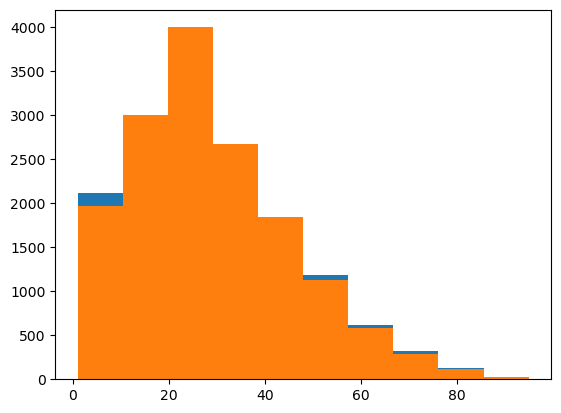

In [5]:
HC = np.round(df.HC.values)+1
nobs = len(HC)
plt.hist(HC)

# Lag-1 hard coral
HC1 = np.round(df.HC_1.values)+1
plt.hist(HC1)

# log lag-1 hard coral
lHC = np.log(HC)
lHC1 = np.log(HC1)

nobs = len(lHC1)

> Nous allons créer nos variables exogènes : `Disturbance`, `UNK` (inconnu), `CoTS`, `Storm`, `Bleaching`, `Disease`, `Herbivory`.
> 
> Les variables continues sont **prétraitées** avec la fonction `clean_and_log` :
>
> - Remplacement des valeurs manquantes (-999)
> - Transformation logarithmique (`log(arr + 1)`)
> - Standardisation  
>
> Les variables résultantes sont stockées sous forme de **arrays NumPy**, prêtes pour l’analyse.

In [18]:
def clean_and_log(arr):
    arr = arr.astype(float).copy()

    arr[arr == -999] = np.mean(arr[arr != -999])

    return stdize(np.log(arr + 1))


# Disturbance
Dist_ = df.DISTURBANCE.values.copy()
Dist_[Dist_ == '-999'] = 'U'
UNK = (Dist_ == 'U') * 1


# CoTS
CoTS = clean_and_log(df.C.values)

# Storm
STORM = clean_and_log(df.S.values)

# Bleaching
BLEACH = clean_and_log(df.B.values)

# Disease
DISEASE = clean_and_log(df.D.values)

# Herbivory
HERB = clean_and_log(df.HERB.values)

> Avant de définir notre modèle Bayésien (`pm.Model()`), il est essentiel de préparer les **indices et covariables** qui seront utilisés pour relier les observations (transects) aux niveaux hiérarchiques supérieurs (récifs et clusters) et pour inclure les effets environnementaux et exogènes dans le modèle.  
>
> **Indexation des clusters et récifs**
>  - Chaque récif est associé à un **cluster** (type de corail) via `subindexall`.
>  - Chaque transect est associé à un **récif** (`indexall`) et à un **cluster** (`indexall`).
>  - Calcul du nombre total de **clusters** (`ncluster`), de **récifs** (`nreefs`) et de **transects par cluster** (`nct`).  
>
> Ces indices permettent de construire les **paramètres hiérarchiques du modèle**, comme `r_Cluster`, `a_Cluster` et `r_Reef`, qui capturent la variation spécifique par cluster et par récif.
>
> **Années de mesure**
>  - Extraction des années de rapport (`REPORT_YEAR`)
>  - Calcul du nombre d’années uniques (`nyears`) et transformation en années relatives depuis 1995 (`YR`)
>  - Définition de l’année maximale relative (`maxyr`)  
> 
> Cette information est nécessaire pour suivre l’évolution de la couverture corallienne **dans le temps** et pour intégrer les effets temporels dans le modèle.

- **Variables exogènes disponibles**  
  - `DIST = ['CoTS','Cyclones','Bleaching','Disease','Unknown']`  
  - **Pourquoi :** ces perturbations sont incluses comme covariables dans le modèle (`g2` à `g6`) pour estimer leur effet direct sur la couverture corallienne.

### Covariables constantes au niveau récif

- **Index récif pour chaque transect**  
  - `rindx` relie chaque transect à son récif  
  - **Pourquoi :** nécessaire pour appliquer les paramètres de récif (`r_Reef`, `a_Reef`) aux transects dans le modèle hiérarchique.

- **Qualité de l’eau**  
  - `WQ` : valeurs de qualité de l’eau pour chaque transect  
  - `Mean_wq` : moyenne de la qualité de l’eau par cluster  
  - `ZcWQ` : qualité de l’eau centrée sur zéro par cluster  
  - **Pourquoi :** ces variables sont utilisées pour estimer l’effet de la qualité de l’eau sur le taux de récupération des récifs (`e0`) et pour créer des interactions avec les perturbations dans le modèle (`g8` à `g11`).

- **Zonage pour résistance et récupération**  
  - `ZONE` : indicateur binaire de zone protégée (résistance)  
  - `rZONE` : valeurs de zonage par récif  
  - **Pourquoi :** ces informations permettent d’estimer l’effet du zonage sur la récupération (`k0`) et les interactions avec les perturbations (`g12` à `g15`).

- **Position sur le plateau continental**  
  - `Shelf, Is = indexall(df.SHELF.values)` : chaque récif a sa position sur le plateau  
  - `nshelf` : nombre de positions distinctes  
  - **Pourquoi :** certaines perturbations comme les cyclones peuvent avoir des effets différents selon la position sur le plateau, ce qui est intégré dans le modèle (`g3[Is]*STORM`).

---

**Résumé :**  
Ces étapes permettent de préparer toutes les **relations hiérarchiques et covariables nécessaires** pour notre modèle Bayésien de dynamique de type Gompertz :  

1. Relier transects → récifs → clusters pour capturer la variabilité hiérarchique.  
2. Intégrer les variables environnementales et exogènes (qualité de l’eau, perturbations, zonage) pour estimer leurs effets sur la couverture corallienne.  
3. Garantir que les paramètres du modèle (taux de croissance, dépendance à la densité, interactions) soient correctement appliqués à chaque niveau hiérarchique.  
4. Faciliter les prédictions et l’interprétation des résultats au niveau des récifs et clusters.

In [20]:
# Indexer chaque récif à un cluster donné
Cluster, Ic = subindexall(df.CLUSTER.values, df.REEF_NAME.values)
ncluster = len(Cluster)

# Indexer chaque transect à un récif donné
Reef,Ir = indexall(df.REEF_NAME.values)
nreefs = len(Reef)

# Indexer chaque transect à un cluster donné
Cluster_t, Ict = indexall(df.CLUSTER.values)
nct = len(Cluster_t)

year = df.REPORT_YEAR.values
nyears = len(np.unique(year))
YR = df.REPORT_YEAR.values - 1995
maxyr = max(YR)

DIST = ['CoTS','Cyclones','Bleaching','Disease','Unknown']

# IIndexer les covariables constantes à l’échelle du récif
rindx = np.array([list(df.REEF_NAME.values).index(x) for x in Reef])

# Obtenir les valeurs de qualité de l’eau
WQ = df.PFsum.values[rindx]
# Moyenne de la qualité de l’eau par cluster
Mean_wq = np.array([np.mean(WQ[Ic == i]) for i in range(ncluster)])
# Qualité de l’eau centrée sur zéro par cluster
ZcWQ = WQ - Mean_wq[Ic]

# Obtenir le zonage pour la résistance
ZONE = (df.iZONE.values + df.sZONE.values>0)*1
# Obtenir les valeurs de zonage pour la récupération
rZONE = ZONE[rindx]

# Obtenir la position du plateau pour chaque récif
Shelf,Is = indexall(df.SHELF.values)
nshelf = len(Shelf)

> Nous définissons ici un **modèle bayésien hiérarchique** implémenté avec `PyMC`.
>
> Contrairement à un modèle fréquentiste classique, la différence principale réside dans la **manière d’estimer les paramètres** :
>
> **Modèle fréquentiste** :
>  - les paramètres sont **fixes mais inconnus**
>  - on estime une **valeur ponctuelle** (ex : maximum de vraisemblance)
>  - l’incertitude est résumée a posteriori (intervalles de confiance)
>
> **Modèle bayésien (PyMC)** :
>  - les paramètres sont des **variables aléatoires**
>  - on estime une **distribution a posteriori complète** pour chaque paramètre
>  - l’incertitude est **directement intégrée dans le modèle**
>
> Le caractère **hiérarchique** (ou à effets mixtes) existe dans les deux cadres, mais :
>
> - en bayésien, il est formulé avec des **priors explicites**
> - et permet une **propagation complète de l’incertitude entre niveaux**
>
> Le modèle est explicitement **hiérarchique à plusieurs niveaux** :
>
> **Niveau 1 : Cluster (type de corail)**
> - `r_Cluster` : taux de croissance intrinsèque par type de corail  
> - `a_Cluster` : dépendance à la densité (Gompertz)
>
> Ce niveau capture les différences biologiques entre types de coraux.
>
> **Niveau 2 : Récif (imbriqué dans les clusters)**
> - `r_Reef ~ Normal(r_Cluster + effets environnementaux)`
> - `a_Reef ~ Normal(a_Cluster, ...)`
>
> Chaque récif a ses propres paramètres, mais ils sont centrés sur le cluster auquel il appartient. C’est le **cœur du modèle hiérarchique** : **les récifs héritent des propriétés de leur cluster, tout en gardant leur spécificité**.
>
> **Niveau 3 : Transect (niveau observationnel)**
>
> Le modèle final (`mu`) est défini à l’échelle du transect :
> la dynamique de type **Gompertz** dépend de :
>  - état passé (`lHC1`)
>  - paramètres du récif (`r_Reef`, `a_Reef`)
>  - perturbations (CoTS, cyclones, etc.)
>  - interactions (qualité de l’eau, zoning)
>
> Les variables exogènes interviennent à deux niveaux :
> **Effets sur la récupération**
> - `WQ` (qualité de l’eau)  
> - `ZONE` (protection)
>
> **Effets des perturbations**
> - CoTS, cyclones, blanchissement, maladies, etc.
> avec interactions :
> - `WQ × perturbations`
> - `ZONE × perturbations`>
>
> Il s’agit d’un **modèle hiérarchique** estimé **dans un cadre bayésien** avec PyMC, structuré principalement par type de corail (cluster) et récif, permettant un partage d’information entre niveaux (partial pooling), dans lequel la dimension Shelf est partiellement intégrée via les effets des cyclones mais ne constitue pas un niveau hiérarchique à part entière.

In [22]:
Model = pm.Model()

# Modèle de dynamique basé sur Gompertz
with Model:
    # Taux de croissance spécifique à chaque cluster
    r_Cluster = pm.Normal('r_Cluster', mu=1.2, sigma=100, shape=ncluster)
    # Dépendance à la densité spécifique à chaque cluster
    a_Cluster = pm.Normal('a_Cluster', mu=0.3, sigma=100, shape=ncluster)
    
    # Variabilité intra-cluster
    sigma_r = pm.Uniform('sigma_r', lower=0, upper=100, shape=ncluster)
    sigma_a = pm.Uniform('sigma_a', lower=0, upper=100, shape=ncluster)

    # Effet du zonage sur le taux de récupération
    k0 = pm.Normal('Zone', mu=0.0, tau=0.001)
    # Effet de la qualité de l'eau sur le taux de récupération
    e0 = pm.Normal('WQ', mu=0.0, tau=0.001)
    
    # Modèle du taux de récupération par récif
    mu_r_reef = r_Cluster[Ic] + k0 * rZONE + e0 *WQ
    r_Reef = pm.Normal('r_Reef', mu=mu_r_reef, sigma=sigma_r[Ic], shape=nreefs)
    
    # Intercepts du paramètre de dépendance à la densité par récif
    a_Reef = pm.Normal('a_Reef', mu=a_Cluster[Ic], sigma=sigma_a[Ic], shape=nreefs)
    
    # Effets directs des perturbations sur la couverture de corail dur
    k2 = pm.Normal('CoTS', mu=0.0, sigma=100)
    s2 = pm.Uniform('SD_CoTS', lower=0.001, upper=100)
    g2 = pm.Normal('cots_', mu=k2, sigma=s2, shape=ncluster)
    k3 = pm.Normal('Storms', mu=0.0, sigma=100)
    s3 = pm.Uniform('SD_Storms', lower=0.001, upper=100)
    g3 = pm.Normal('Cyclones', mu=k3, sigma=s3, shape=nshelf)
    g4 = pm.Normal('Bleaching', mu=0.0, sigma=100)
    g5 = pm.Normal('Disease', mu=0.0, sigma=100)
    g6 = pm.Normal('Unknown', mu=0.0, sigma=100)
    
    # Effet de l’herbivorie sur le taux de récupération
    g7 = pm.Normal('Herbivory', mu=0.0, sigma=100)
    
    # Interactions qualité de l’eau × perturbations
    g8 = pm.Normal('WQ_bleach', mu=0.0, sigma=100)
    g9 = pm.Normal('WQ_CoTS', mu=0.0, sigma=100)
    g10 = pm.Normal('WQ_Disease', mu=0.0, sigma=100)
    g11 = pm.Normal('WQ_Unknown', mu=0.0, sigma=100)
    
    # Interactions zonage × perturbations
    g12 = pm.Normal('Z_bleach', mu=0.0, sigma=100)
    g13 = pm.Normal('Z_CoTS', mu=0.0, sigma=100)
    g14 = pm.Normal('Z_Disease', mu=0.0, sigma=100)
    g15 = pm.Normal('Z_Unknown', mu=0.0, sigma=100)
    
    # Modèle au niveau du transect
    mu = (r_Reef[Ir]+g7*HERB)+(1.-a_Reef[Ir])*lHC1+g2[Ict]*CoTS+g3[Is]*STORM+g4*BLEACH+g5*DISEASE+g6*UNK+g8*BLEACH*WQ[Ir]+g9*CoTS*WQ[Ir]+g10*DISEASE*WQ[Ir]+g11*UNK*WQ[Ir]+g12*BLEACH*ZONE+g13*CoTS*ZONE+g14*DISEASE*ZONE+g15*UNK*ZONE
    
    # Link function
    #logmu = tt.exp(mu)/100.
    
    # Likelihood
    #Yi = pm.Binomial('Yi', n=100, p=logmu, observed=HC)

    p = pm.math.sigmoid(mu)  # ensures 0 < p < 1
    Yi = pm.Binomial('Yi', n=100, p=p, observed=HC)


> Une fois défini, le modèle, nous pouvons lancer l’entraînement.

In [23]:
# Sampling
with Model:
    # Draw samples using NUTS
    trace = pm.sample(1000, tune=1000, cores=2)

C:\Users\lenov\anaconda3\envs\pymc_ofb\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [r_Cluster, a_Cluster, sigma_r, sigma_a, Zone, WQ, r_Reef, a_Reef, CoTS, SD_CoTS, cots_, Storms, SD_Storms, Cyclones, Bleaching, Disease, Unknown, Herbivory, WQ_bleach, WQ_CoTS, WQ_Disease, WQ_Unknown, Z_bleach, Z_CoTS, Z_Disease, Z_Unknown]


C:\Users\lenov\anaconda3\envs\pymc_ofb\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1021 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


> Nous sauvegardons maintenant les résultats dans une variable appelée `summary_df`.

In [24]:
summary_df = pm.stats.summary(trace)

> La richesse de notre modèle vient du fait que nous avons estimé un grand nombre de paramètres (133) et, pour chacun d’entre eux, nous avons obtenu une **distribution complète**.
Nous affichons ici les dimensions de la table ainsi que ses premières et dernières lignes pour en avoir un aperçu.

In [29]:
print(f"Notre modèle a estimé {summary_df.shape[0]} paramètres avec {summary_df.shape[1]} statistiques par paramètre.")
print(summary_df.tail(10))
summary_df.head(10)

Notre modèle a estimé 133 paramètres avec 9 statistiques par paramètre.
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
sigma_r[0]  0.771  0.266   0.390    1.239      0.006    0.011    2701.0   
sigma_r[1]  0.444  0.131   0.235    0.672      0.003    0.005    1796.0   
sigma_r[2]  0.495  0.174   0.260    0.814      0.005    0.010    2158.0   
sigma_r[3]  0.428  0.105   0.251    0.618      0.002    0.003    2200.0   
sigma_a[0]  0.273  0.090   0.146    0.425      0.003    0.005    2288.0   
sigma_a[1]  0.145  0.036   0.085    0.208      0.001    0.001    2652.0   
sigma_a[2]  0.123  0.042   0.059    0.202      0.001    0.002    2093.0   
sigma_a[3]  0.147  0.035   0.090    0.217      0.001    0.001    2538.0   
SD_CoTS     0.309  0.430   0.061    0.694      0.020    0.099     758.0   
SD_Storms   1.193  4.218   0.039    3.735      0.443    1.201     149.0   

            ess_tail  r_hat  
sigma_r[0]    1583.0   1.00  
sigma_r[1]    1398.0   1.00  
sigma_r[2]  

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
r_Cluster[0],-4.467,0.372,-5.120,-3.749,0.008,0.009,2332.0,1648.0,1.0
r_Cluster[1],-4.710,0.174,-5.042,-4.385,0.004,0.004,2075.0,1611.0,1.0
r_Cluster[2],-4.549,0.200,-4.928,-4.172,0.004,0.006,2246.0,1416.0,1.0
r_Cluster[3],-4.160,0.130,-4.382,-3.888,0.003,0.003,2242.0,1451.0,1.0
a_Cluster[0],-0.132,0.099,-0.327,0.041,0.003,0.005,1987.0,485.0,1.0
a_Cluster[1],-0.193,0.042,-0.275,-0.121,0.001,0.001,2901.0,1341.0,1.0
a_Cluster[2],-0.166,0.046,-0.252,-0.076,0.001,0.001,2582.0,1317.0,1.0
a_Cluster[3],0.044,0.040,-0.030,0.118,0.001,0.001,3002.0,1454.0,1.0
Zone,0.030,0.172,-0.292,0.354,0.004,0.004,2361.0,1548.0,1.0
WQ,-0.637,0.384,-1.446,0.012,0.008,0.008,2435.0,1753.0,1.0


> Le tableau `summary_df` contient pour chaque paramètre plusieurs statistiques importantes pour évaluer les estimations et la qualité des chaînes MCMC :
>
> - **mean** : moyenne de la distribution a posteriori, représentant la valeur centrale estimée du paramètre.  
> - **sd** : écart-type de la distribution, mesurant l’incertitude autour de la moyenne.  
> - **hdi_3% et hdi_97%** : bornes inférieure et supérieure de l’intervalle de crédibilité à 94 % (Highest Density Interval), indiquant l’intervalle où se trouvent la majorité des valeurs de la distribution. > - **mcse_mean et mcse_sd** : erreur standard Monte Carlo pour la moyenne et l’écart-type, évaluant la précision des estimations dues à l’échantillonnage MCMC.  
> - **ess_bulk et ess_tail** : effective sample size pour le corps et les queues de la distribution ; un indicateur de la qualité de l’échantillonnage et de la convergence.  
> - **r_hat** : statistique de Gelman-Rubin ; une valeur proche de 1.0 indique que la chaîne MCMC a bien convergé.
>
> par exemple our `r_Cluster[0]` :  

| Paramètre       | mean   | sd    | hdi_3%  | hdi_97% |
|-----------------|--------|-------|---------|---------|
| r_Cluster[0]    | -4.467 | 0.372 | -5.120  | -3.749  |

> - La moyenne (-4.467) représente la valeur centrale estimée du taux de croissance pour le premier cluster.  
> - L’écart-type (0.372) et l’intervalle de crédibilité [-5.120, -3.749] montrent l’incertitude autour de cette estimation.  
> - Un `r_hat = 1.0` et des ESS élevés confirment une bonne convergence des chaînes MCMC.

> Cette table et ces métriques permettent de vérifier la fiabilité et la précision de toutes les estimations de paramètres du modèle.
>
> Passons au diagnostic du modèle.  
>
> Nous utilisons la fonction `plot_trace` d’ArviZ pour **visualiser les chaînes MCMC des paramètres**. Concrètement, pour chaque paramètre, elle produit **deux graphiques côte à côte** :
>
> **Trace plot**
> - Montre les **valeurs échantillonnées à chaque itération** pour chaque chaîne MCMC.  
> - Permet de **vérifier la convergence** : si la chaîne “saute partout” ou est instable → problème.  
> - Chaque ligne colorée représente une **chaîne distincte**.
>
> **Histogramme / densité a posteriori**
> - Montre la **distribution estimée du paramètre** à partir des échantillons.  
> - La forme de cette distribution correspond à l’**incertitude bayésienne** du paramètre.

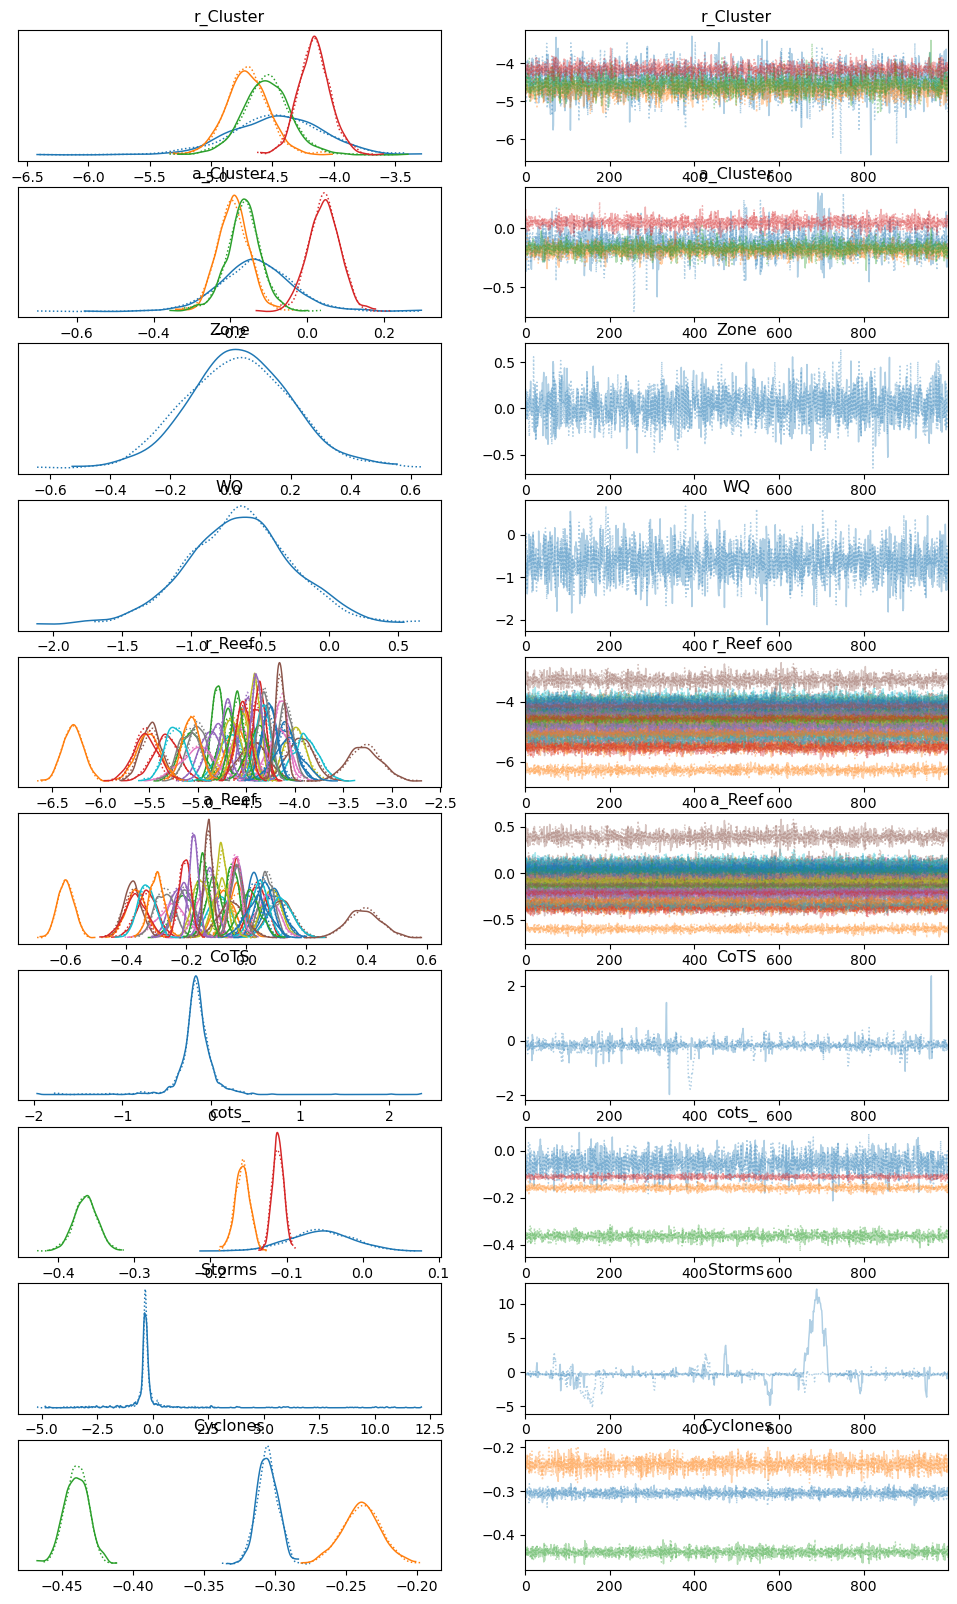

In [37]:
all_params = list(trace.posterior.data_vars)  # trace doit être converti en InferenceData si besoin
first_10_params = all_params[:10]
az.plot_trace(trace, var_names=first_10_params);

> L’entraînement du modèle est très long (15–20 minutes). Nous sauvegardons donc les résultats dans un fichier CSV afin que, pour l’interprétation et l’inférence, nous n’ayons pas besoin de relancer le modèle.

In [56]:
summary_df.to_csv("../data/summary_trace.csv", index=True) 

> Nous pouvons maintenant utiliser les paramètres estimées pour prédire l'évolution de la couvertuer coralienne sur les années futures. 

In [63]:
# -----------------------------
# Années futures
# -----------------------------
years_future = np.arange(2018, 2023)  # 2018-2022
n_years = len(years_future)


# -----------------------------
# Clusters
# -----------------------------
Cluster_unique = np.array(df['CLUSTER'].unique())
ncluster = len(Cluster_unique)


# -----------------------------
# Récifs
# -----------------------------
Reefs = np.array(df['REEF_NAME'].unique())
nreefs = len(Reefs)

# Cluster associé à chaque récif
Ic_reef = np.array([
    df['CLUSTER'][df['REEF_NAME'] == r].iloc[0]
    for r in Reefs
])

cluster_to_index = {cl: i for i, cl in enumerate(Cluster_unique)}
Ic_reef_idx = np.array([cluster_to_index[c] for c in Ic_reef])


# -----------------------------
# HC par récif (année initiale)
# -----------------------------
HC_by_reef = np.array([
    np.mean(HC[Ir == r]) for r in range(nreefs)
])

HC_last = np.log(HC_by_reef + 1)


# -----------------------------
# Covariables par cluster
# -----------------------------
CoTS_by_cluster = np.array([
    np.mean(CoTS[Ict == i]) for i in range(ncluster)
])

BLEACH_by_cluster = np.array([
    np.mean(BLEACH[Ict == i]) for i in range(ncluster)
])

DISEASE_by_cluster = np.array([
    np.mean(DISEASE[Ict == i]) for i in range(ncluster)
])

UNK_by_cluster = np.array([
    np.mean(UNK[Ict == i]) for i in range(ncluster)
])

HERB_by_reef = np.array([
    np.mean(HERB[Ir == r]) for r in range(nreefs)
])


# -----------------------------
# Dimensions MCMC
# -----------------------------
n_chains = trace.posterior.dims['chain']
n_draws = trace.posterior.dims['draw']

n_samples = n_chains * n_draws


# -----------------------------
# Extraction des paramètres
# -----------------------------

# (chain, draw, reef) → (samples, reef)
r_Reef_all = trace.posterior['r_Reef'].values.reshape(n_samples, nreefs)
a_Reef_all = trace.posterior['a_Reef'].values.reshape(n_samples, nreefs)

# (chain, draw, cluster) → (samples, cluster)
cots_all = trace.posterior['cots_'].values.reshape(n_samples, ncluster)

# (chain, draw) → (samples,)
bleach_all = trace.posterior['Bleaching'].values.reshape(n_samples)
disease_all = trace.posterior['Disease'].values.reshape(n_samples)
unk_all = trace.posterior['Unknown'].values.reshape(n_samples)
herb_all = trace.posterior['Herbivory'].values.reshape(n_samples)


# -----------------------------
# Tableau de sortie
# -----------------------------
HC_future = np.zeros((n_samples, ncluster, n_years))


# -----------------------------
# Simulation
# -----------------------------
for t, year in enumerate(years_future):

    print(f"Prédictions pour {year}...")

    for i in range(n_samples):

        # Paramètres i
        r_Reef_i = r_Reef_all[i]
        a_Reef_i = a_Reef_all[i]

        g2_i = cots_all[i]
        g4_i = bleach_all[i]
        g5_i = disease_all[i]
        g6_i = unk_all[i]
        g7_i = herb_all[i]


        # Prédiction par cluster
        HC_pred_cluster = np.zeros(ncluster)

        for c in range(ncluster):

            idx_reef = Ic_reef_idx == c

            mu = (
                np.mean(r_Reef_i[idx_reef]
                        + g7_i * HERB_by_reef[idx_reef])
                + (1 - np.mean(a_Reef_i[idx_reef])) * HC_last[c]
                + g2_i[c] * CoTS_by_cluster[c]
                + g4_i * BLEACH_by_cluster[c]
                + g5_i * DISEASE_by_cluster[c]
                + g6_i * UNK_by_cluster[c]
            )

            # Logit → probabilité
            p = 1 / (1 + np.exp(-mu))

            # Simulation binomiale
            HC_pred_cluster[c] = np.random.binomial(n=100, p=p)


        HC_future[i, :, t] = HC_pred_cluster


    # Mise à jour HC pour année suivante
    HC_last = np.log(HC_future[:, :, t].mean(axis=0) + 1)


# -----------------------------
# DataFrame pour plotting
# -----------------------------
data_plot = []

HC_median = np.median(HC_future, axis=0)

for t, year in enumerate(years_future):

    for c, cl in enumerate(Cluster_unique):

        data_plot.append({
            'REPORT_YEAR': year,
            'HC': HC_median[c, t],
            'CLUSTER': cl
        })


df_plot = pd.DataFrame(data_plot)
df_plot

C:\Users\lenov\AppData\Local\Temp\ipykernel_24564\2583256445.py:68: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = trace.posterior.dims['chain']
C:\Users\lenov\AppData\Local\Temp\ipykernel_24564\2583256445.py:69: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_draws = trace.posterior.dims['draw']


Prédictions pour 2018...
Prédictions pour 2019...
Prédictions pour 2020...
Prédictions pour 2021...
Prédictions pour 2022...


,REPORT_YEAR,HC,CLUSTER
0,2018,22.0,Porities-A
1,2018,20.0,Mixed
2,2018,31.0,Acropora
3,2018,35.0,Soft-coral
4,2019,23.0,Porities-A
5,2019,23.0,Mixed
6,2019,37.0,Acropora
7,2019,32.0,Soft-coral
8,2020,23.0,Porities-A
9,2020,26.0,Mixed


> Et nous allons maintenant visualiser les predictions pour les années futures à l'echelle des clusteurs

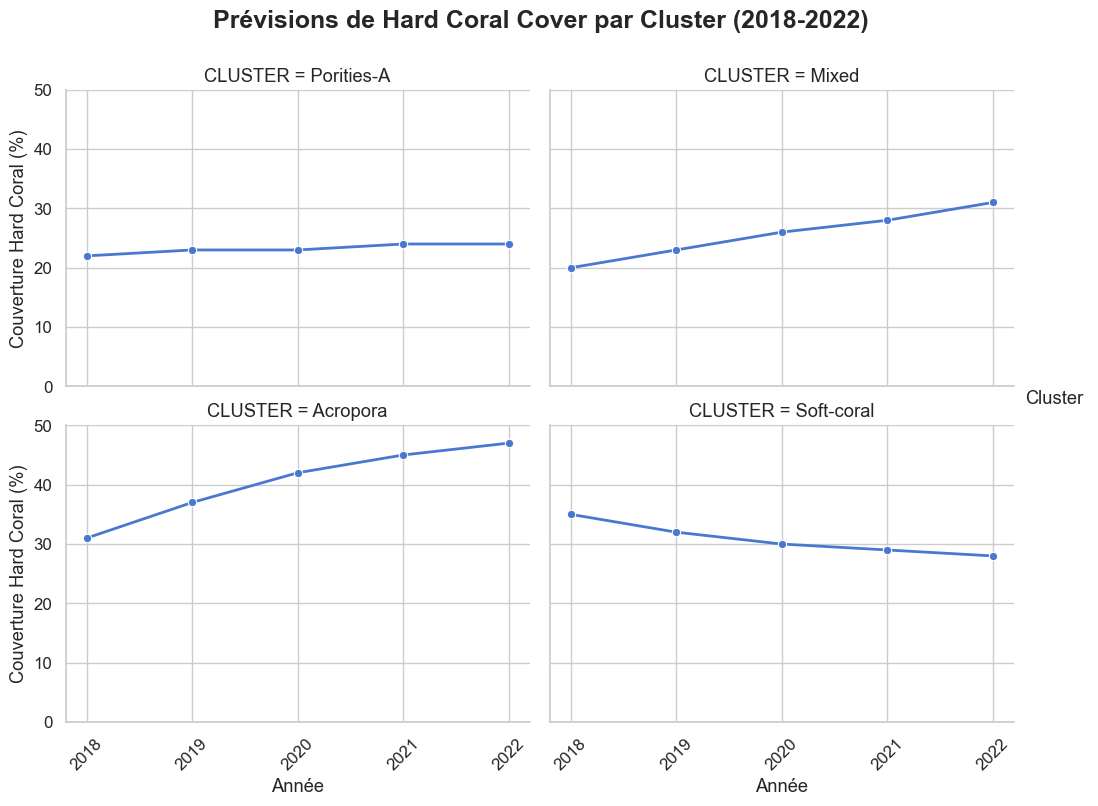

In [70]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Création du relplot
g = sns.relplot(
    data=df_plot,
    x='REPORT_YEAR',
    y='HC',
    col='CLUSTER',
    kind='line',
    col_wrap=2,
    height=4,
    aspect=1.3,
    marker='o',
    linewidth=2
)

# Ajouter un titre global
g.fig.suptitle(
    "Prévisions de Hard Coral Cover par Cluster (2018-2022)",
    fontsize=18,
    fontweight='bold'
)

g.fig.subplots_adjust(top=0.88)

g.set_axis_labels("Année", "Couverture Hard Coral (%)")

for ax in g.axes.flat:
    ax.set_xticks(df_plot['REPORT_YEAR'].unique())
    ax.set_xticklabels(df_plot['REPORT_YEAR'].unique(), rotation=45)
    ax.set_ylim(0, 50) 

g.add_legend(title='Cluster')

plt.show()

> et maintenant passons à la prédicitons par récif :

In [75]:
# -----------------------------
# Récifs à prédire
# -----------------------------
reefs_to_plot = Reefs[0:2]  # ou ['ReefA', 'ReefB']
n_plot = len(reefs_to_plot)

# Index des récifs
reef_idx_plot = [np.where(Reefs == r)[0][0] for r in reefs_to_plot]

# Initialisation des prédictions
HC_future_reef = np.zeros((n_samples, n_plot, n_years))
HC_last_reef = np.log(HC_by_reef[reef_idx_plot] + 1)

# -----------------------------
# Simulation par récif
# -----------------------------
for t, year in enumerate(years_future):
    print(f"Prédictions pour {year}...")

    for i in range(n_samples):
        r_Reef_i = r_Reef_all[i]
        a_Reef_i = a_Reef_all[i]
        g2_i = cots_all[i]
        g4_i = bleach_all[i]
        g5_i = disease_all[i]
        g6_i = unk_all[i]
        g7_i = herb_all[i]

        for j, r_idx in enumerate(reef_idx_plot):

            cluster_idx = Ic_reef_idx[r_idx]

            mu = (
                r_Reef_i[r_idx] + g7_i * HERB_by_reef[r_idx]  # récup r et herbivory
                + (1 - a_Reef_i[r_idx]) * HC_last_reef[j]      # densité dépendance
                + g2_i[cluster_idx] * CoTS_by_cluster[cluster_idx]
                + g4_i * BLEACH_by_cluster[cluster_idx]
                + g5_i * DISEASE_by_cluster[cluster_idx]
                + g6_i * UNK_by_cluster[cluster_idx]
            )

            # Logit → probabilité
            p = 1 / (1 + np.exp(-mu))
            HC_future_reef[i, j, t] = np.random.binomial(n=100, p=p)

    # Mise à jour HC pour année suivante
    HC_last_reef = np.log(HC_future_reef[:, :, t].mean(axis=0) + 1)

# -----------------------------
# DataFrame pour plotting
# -----------------------------
data_plot_reef = []
HC_median_reef = np.median(HC_future_reef, axis=0)

for t, year in enumerate(years_future):
    for j, r_name in enumerate(reefs_to_plot):
        data_plot_reef.append({
            'REPORT_YEAR': year,
            'HC': HC_median_reef[j, t],
            'REEF_NAME': r_name
        })

df_plot_reef = pd.DataFrame(data_plot_reef)
df_plot_reef

Prédictions pour 2018...
Prédictions pour 2019...
Prédictions pour 2020...
Prédictions pour 2021...
Prédictions pour 2022...


,REPORT_YEAR,HC,REEF_NAME
0,2018,23.0,MACGILLIVRAY REEF
1,2018,18.0,LIZARD ISLAND
2,2019,24.0,MACGILLIVRAY REEF
3,2019,19.0,LIZARD ISLAND
4,2020,24.0,MACGILLIVRAY REEF
5,2020,20.0,LIZARD ISLAND
6,2021,24.0,MACGILLIVRAY REEF
7,2021,20.0,LIZARD ISLAND
8,2022,25.0,MACGILLIVRAY REEF
9,2022,21.0,LIZARD ISLAND


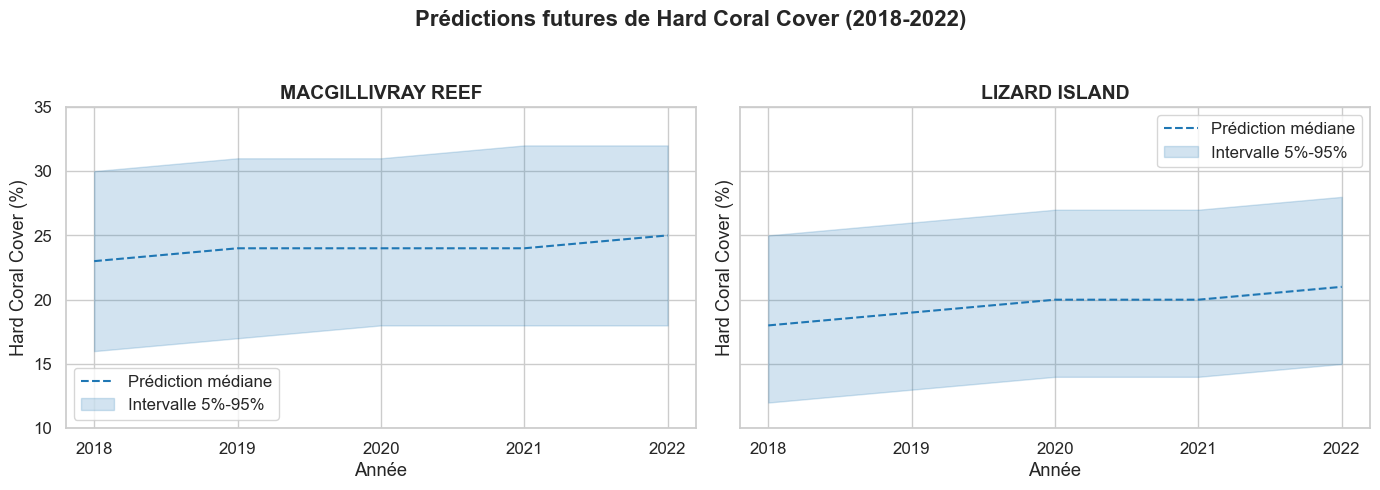

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, r_name in enumerate(reefs_to_plot):
    ax = axes[i]
    ax.plot(years_future, HC_median_reef[i, :], 
            color='tab:blue', linestyle='--', label='Prédiction médiane')
    ax.fill_between(years_future, 
                    HC_low_reef[i, :], 
                    HC_high_reef[i, :], 
                    color='tab:blue', alpha=0.2, label='Intervalle 5%-95%')
    ax.set_title(r_name, fontsize=14, fontweight='bold')
    ax.set_xlabel("Année")
    ax.set_ylabel("Hard Coral Cover (%)")
    ax.set_xticks(years_future)
    ax.set_ylim(10, 35)
    ax.legend()

fig.suptitle("Prédictions futures de Hard Coral Cover (2018-2022)", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Conclusion

> Nous avons utilisé ici une approche statistique bayésienne hiérarchique pour modéliser l'évolution de la couverture coralienne. 
>
> L'avantage de cette approche réside dans le fait que nous estimons les paramètres à l'échelle des transects, en intégrant la variabilité observée à travers les transects, les sites, les récifs et les clusters.
>
> Contrairement à une approche classique de type machine learning, où l'on se limite souvent à une seule mesure par récif et par année, ce modèle exploite pleinement la structure hiérarchique des données.
> 
> De plus, la dimension temporelle est intégrée via la variable `HC_1`, permettant de capturer les effets de l'état passé sur la dynamique actuelle du corail. Enfin, cette approche nous permet de prendre en compte explicitement les effets des variables exogènes telles que les perturbations (CoTS, cyclones, blanchissement, maladies, etc.), offrant ainsi une modélisation écologiquement réaliste et robuste.